# Implementation of the example in Appendix C of the thesis of Antoine Dumas:

## Application appui plan et deux goupilles

In [1]:
import math
import sympy as sp
import numpy as np
from typing import List, Tuple
from functools import partial
from scipy.optimize import NonlinearConstraint, Bounds, minimize
from IPython import display

import otaf
from gldpy import GLD

Since the implementation in dumas work is a bit different and that we don't really care about the linerization rn, we have to ceate some intermediary functions for the optimization.

We have multiple sets of variables, and the optimization is only done on the gap varibles (g), meaning we need to have a first function that fixes the other variables (using partial) or something, so that we have in the end only a function that takes as an input the gaps.

### Original values from dumas work (we choose parameter set 1)

In [2]:
L = [100, 40, 30, 30, 20, 20, 120, 50, 40, 50, -30]
d_max = 0.25

mu_d_ext = 20
sigma_d_ext = 0.06

mu_d_int = 19.8
sigma_d_int = 0.06

mu_trans = 0
sigma_trans = 0.01
mu_rot = 0 
sigma_rot = 0.001

st = sigma_trans
sr = sigma_rot

### Let's use the equations in C.15 to calculate the equivalent distribution parameters.

Since all mean shifts are 0, the meansz of the rotational components are also 0

In [3]:
const = L[0]*L[10] - L[1]*L[9] 
sigma_beta_d_0 = np.sqrt(((L[0]/const)*st)**2 +(((L[9]-L[0])/const)*st)**2 +((L[9]/const)*st)**2)
sigma_gamma_d_0 = np.sqrt(((L[1]/const)*st)**2 +(((L[10]-L[1])/const)*st)**2 +((L[10]/const)*st)**2)
sigma_beta_d_1 = np.sqrt(((L[0]/const)*st)**2 +(((L[9]-L[0])/const)*st)**2 +((L[9]/const)*st)**2)
sigma_gamma_d_1 = sigma_gamma_d_0
sigma_beta_d_2 = np.sqrt(2*(st**2)/(L[2])**2)
sigma_gamma_d_2 = np.sqrt(2*(st**2)/(L[2])**2)
sigma_beta_d_3 = np.sqrt(2*(st**2)/(L[4])**2)
sigma_gamma_d_3 = np.sqrt(2*(st**2)/(L[4])**2)
sigma_beta_d_4 = np.sqrt(2*(st**2)/(L[3])**2)
sigma_gamma_d_4 = np.sqrt(2*(st**2)/(L[3])**2)
sigma_beta_d_5 = np.sqrt(2*(st**2)/(L[5])**2)
sigma_gamma_d_5 = np.sqrt(2*(st**2)/(L[5])**2)

These values are only valid for the parameterization where the position of the two upper and lower circles at the end of the cylindrical features is modeled, not the orientation and position of the cylindrical feature itself. We want on the other hand have parameters to model that, and find and equivalent set of parameters.

More specifically, we need a tolerance and capability value to use as knowledge constraints.

Since we have a feature (a circle), and a set of distribution parameters that controls the diameter and the position of this circle, we can suppose that we have a tolerance zone that is the zone between 2 concentric circles.

We can arbitrarily fix the capability to some values, let's say 1, and find the tolerance value. Under the assumption of a centered normal distribution, a capability of $C_p=1$ implies that the tolerance width is $6 \sigma$. The probability of failure is thus the area under the tails where $|Z|>3$, calculated as $2(1−P(X \leq 3))$, which is equal to $2.699796 \cdot 1e^{-3}$.

Using the parameters sigma_d_ext and sigma_trans and inject it in the formula for the local circular defect (the defect is centered on the nominal), then we can treat this as a traditional case fo having a normal distribution within a tolerance interval $t$. 

We have $\sigma_\delta = t / 6C$, since $C=1$, $t=6*\sigma_\delta$

In [4]:
std_delta_cyl = np.sqrt(sigma_d_ext**2 + sigma_trans**2)
# This is from the formula for the standard deviation of the measured defect for a circular tolerance zone
# So this is our target in optimization
print(std_delta_cyl)
# For thea measured defect on the planar feature the target is sigma_trans (already a measured standard)

0.0608276253029822


In [5]:
def sigma_delta_circular_feature(theta, sr=sigma_d_ext, su=sigma_trans, sv=sigma_trans):
    """This function is used to obtain the standard deviation of the defect for a point in the circular features 
    This can also be used as a basis for a constraint function (to always have the same max standard deviation over the circular feature)
    """
    return np.sqrt(sr**2 + np.cos(theta)**2 * su**2 + np.sin(theta)**2 * sv**2)

def sigma_delta_3D_plane(x,y, sw=sigma_trans, sa=sigma_rot, sb=sigma_rot):
    """This function is used to obtain the standard deviation of the defect for a point on the plane feature 
    This can also be used as a basis for a constraint function
    """
    return np.sqrt(sw**2 + y**2 * sa**2 + x**2 * sb**2)

def sigma_delta_cylindrical_feature(z, theta, sr, su, salpha, sv, sbeta):
    return np.sqrt(sr**2 + (su**2+(sbeta*z)**2)*np.cos(theta)**2 + (sv**2+(salpha*z)**2)*np.sin(theta)**2)

In [6]:
# Let's find te values for sigma_v_d_2 and sigma_w_d_2
# We should have sigma_delta_circular_feature(0, sigma_d_ext, sigma_trans, sigma_trans) = sigma_delta_cylindrical_feature(L[k]/2, 0, sigma_d_ext, sigma_v_d_2, sigma_gamma_d_2, sigma_w_d_2, sigma_beta_d_2)
# with sigma_v_d_2 = sigma_w_d_2

In [7]:
target = sigma_delta_circular_feature(0)
f1=lambda x: sigma_delta_cylindrical_feature(L[2]/2, 0, sigma_d_ext, x, sigma_gamma_d_2, x, sigma_beta_d_2) - target
f2=lambda x: sigma_delta_cylindrical_feature(L[4]/2, 0, sigma_d_ext, x, sigma_gamma_d_3, x, sigma_beta_d_3) - target
f3=lambda x: sigma_delta_cylindrical_feature(L[3]/2, 0, sigma_d_ext, x, sigma_gamma_d_4, x, sigma_beta_d_4) - target
f4=lambda x: sigma_delta_cylindrical_feature(L[5]/2, 0, sigma_d_ext, x, sigma_gamma_d_5, x, sigma_beta_d_5) - target

In [8]:
from scipy.optimize import fsolve
# 0 is a common starting guess for these types of geometric features
st_d_2 = fsolve(f1, x0=1e-6)[0]
st_d_3 = fsolve(f2, x0=1e-6)[0]
st_d_4 = fsolve(f3, x0=1e-6)[0]
st_d_5 = fsolve(f4, x0=1e-6)[0]
print(st_d_2, st_d_3, st_d_4, st_d_5)

0.007071067811865524 0.007071067811865524 0.007071067811865524 0.007071067811865524


In [9]:
# Here we define our constraints for the target standard deviations for each feature
# Since we disregard mean shifts We can directly use the expression of the standard deviation 
# of the measured defect
# We must find the max though, at least for the circular feature since for the plane it is on the corners
# We also don't include any correlation yet

This means that the cylindrical feature must be within two cylinders of radius difference of t_eq

We'll also obtain the 

In [10]:
mats = otaf.example_models.model_dumas_cython.build_constraint_matrices(L,32)

In [11]:
SOCAM =otaf.SystemOfConstraintsAssemblyModel(matrices=list(mats))

In [12]:
d_labels = [sp.Symbol(otaf.example_models.model_dumas_cython.x_full_labels_mapping[lab]) for lab in otaf.example_models.model_dumas_cython.x_full_labels]
g_labels = [sp.Symbol(otaf.example_models.model_dumas_cython.g_labels_mapping[lab]) for lab in otaf.example_models.model_dumas_cython.g_labels]
SOCAM.deviation_symbols = d_labels
SOCAM.gap_symbols = g_labels
SOCAM.embedOptimizationVariable()

In [13]:
SOCAM.test_zero_deviation_feasibility()

{'success': True,
 'status': 0,
 'message': 'Optimization terminated successfully. (HiGHS Status 7: Optimal)',
 'gap_values': array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
        -0., -0., -0., -0., -0.]),
 'objective': 0.0}

In [14]:
sigma_beta_d_4

np.float64(0.0004714045207910317)

In [15]:
mu_list = [.0]*22+[mu_d_ext,mu_d_int,mu_d_ext,mu_d_int]+[.0]*4
sigma_list = [st, sigma_beta_d_0, sigma_gamma_d_0, 
              st, sigma_beta_d_1, sigma_gamma_d_1,
              st, st, sigma_beta_d_2, sigma_gamma_d_2,
              st, st, sigma_beta_d_3, sigma_gamma_d_3,
              st, st, sigma_beta_d_4, sigma_gamma_d_4,
              st, st, sigma_beta_d_5, sigma_gamma_d_5,
              sigma_d_ext,sigma_d_int,sigma_d_ext,sigma_d_int,
              st, st, sr, sr]#

In [16]:
    # The gap vector is of dimension 16 + 1 (due to the added slack variable)
deviation_symbols = otaf.example_models.model_dumas_cython.x_full_labels
# Here we have a distribution in the standard space. 
defect_distribution = otaf.distribution.get_composed_normal_defect_distribution(
    deviation_symbols,
    mu_list = mu_list,
    sigma_list = sigma_list)
sample_U_50000 = np.array(defect_distribution.getSample(10000))

In [17]:
outs = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(SOCAM, sample_U_50000, n_cpu=7)

In [18]:
slack = outs[:,-1]

In [19]:
gld = GLD('VSL')
gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
fp_slack = np.where(slack<0,1,0).mean()
fp_gld = gld.CDF_num(0, gld_params)

In [20]:
print("proba failure sample:", fp_slack)
print("proba failure gld:", fp_gld)

proba failure sample: 0.0569
proba failure gld: [0.05828722]


In [21]:
## NN surrogate to hopefully make things a bit faster.
# Define the seed, sample size, and file paths
SEED = 420  # Example seed value
sample_size = 100000

# Ensure reproducibility by setting the seed
np.random.seed(SEED)

# Generate the sample
dist = otaf.distribution.multiply_composed_distribution_standard_with_constants(
    defect_distribution, [2.0]*22+[2.0]*4+[2.0]*4) # We now work with low failure probabilities so we increase the dispresion to have more failed parts for the training
#TRAIN_SAMPLE = np.array(otaf.uncertainty.generateLHSExperiment(dist, sample_size))
TRAIN_SAMPLE = np.array(otaf.sampling.generate_and_transform_sequence(30,sample_size,dist),dtype="float32")
# Compute the results
TRAIN_RESULTS = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
    SOCAM,
    TRAIN_SAMPLE,
    bounds=None,
    n_cpu=-2,
    progress_bar=True,
    batch_size=500,
    dtype="float32"
)

# Assign X and y from TRAIN_SAMPLE and TRAIN_RESULTS
Xtrain = TRAIN_SAMPLE
ytrain = TRAIN_RESULTS
print(f"Ratio of failed simulations in sample : {np.where(ytrain[:,-1]<0,1,0).sum()/sample_size}")

  0%|          | 0/100000 [00:00<?, ?it/s]

Ratio of failed simulations in sample : 0.40854


[30, 159, 77, 24, 1]


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 001, Val Loss: 0.950793, Val R2: -618.982056


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 002, Val Loss: 0.865757, Val R2: -91.502747


...

Epoch 248, Val Loss: 0.001963, Val R2: 0.998038


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 249, Val Loss: 0.001949, Val R2: 0.998052


  0%|          | 0/2 [00:00<?, ?batch/s]

Epoch 250, Val Loss: 0.001935, Val R2: 0.998066
Finished training at epoch 250 with best loss 0.001935 and R2 of 0.998066


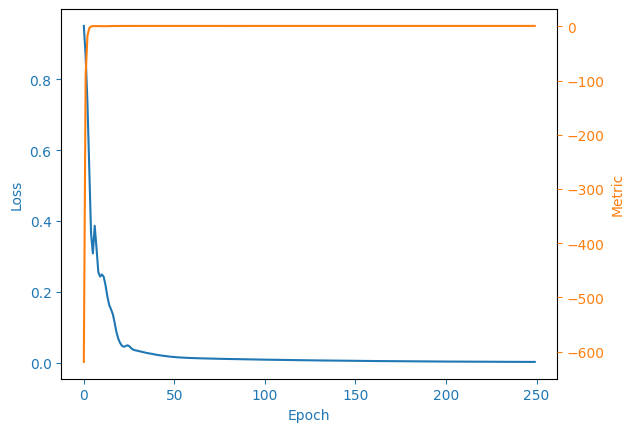

In [22]:
import torch
dim = int(defect_distribution.getDimension())
neural_model = otaf.surrogate.NeuralRegressorNetwork(
    dim, 1,
    Xtrain, ytrain[:,-1], 
    clamping=True, 
    finish_critertion_epoch=5,
    loss_finish=1e-6, 
    metric_finish=0.99999, 
    max_epochs=250, 
    batch_size=30000, 
    compile_model=False, 
    train_size=0.6, 
    input_description=defect_distribution.getDescription(),
    display_progress_disable=False)

lr=0.003

#neural_model.model = KAN([dim, 8, 4, 1])  #otaf.surrogate.get_base_relu_mlp_model(dim, 1, False)

neural_model.model = torch.nn.Sequential(
    *otaf.surrogate.get_custom_mlp_layers([dim, 120, 80, 35, 1], activation_class=torch.nn.GELU)
)

neural_model.optimizer = torch.optim.AdamW(neural_model.parameters(), lr=lr, weight_decay=1e-4)
otaf.surrogate.initialize_model_weights(neural_model)
neural_model.scheduler =  torch.optim.lr_scheduler.ExponentialLR(neural_model.optimizer, 1.0001)
neural_model.loss_fn = torch.nn.MSELoss()
#neural_model.loss_fn = otaf.uncertainty.LimitSpaceFocusedLoss(0.0001, 2, square=True) # otaf.uncertainty.PositiveLimitSpaceFocusedLoss(0.0001, 2, 4, square=False)


neural_model.train_model()
neural_model.plot_results()

In [23]:
slack = np.squeeze(neural_model.evaluate_model_non_standard_space(sample_U_50000).detach().numpy())
gld = GLD('VSL')
gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
fp_slack = np.where(slack<0,1,0).mean()
fp_gld = gld.CDF_num(0, gld_params)
print("proba failure sample:", fp_slack)
print("proba failure gld:", fp_gld)

proba failure sample: 0.0596
proba failure gld: [0.06060425]


## We have similar values to those found by A. Dumas. Continuing.

In [24]:
#Function to store results

result_dict={}

def store_results(x, fp_gld, fp_slack, gld_params, experiment_key=None, result_dict=result_dict):
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    x_dict = {"FP_GLD": fp_gld, "FP_SLACK":fp_slack, "GLD_PARAMS": gld_params}
    if experiment_key is None:
        if x_key in result_dict.keys():
            result_dict[x_key].update(x_dict)
        else :
            result_dict[x_key] = x_dict
    else : 
        if experiment_key not in result_dict:
            result_dict[experiment_key] = {}
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(x_dict)
        else:
            result_dict[experiment_key][x_key] = x_dict

In [25]:
NDim_Defects = len(mu_list)
SIZE_MC_PF = 100000 #int(1e6) #1e4
defect_distribution_standard_normal = otaf.distribution.get_composed_normal_defect_distribution(deviation_symbols)
sample_gld = np.array(defect_distribution_standard_normal.getSample(SIZE_MC_PF))
scale_factor = 1.0
GLD_parameters = [] # We need the parameters of the generalized lambda distribution.

result_list = [] # Will be list of lists, where each sub list is a list of the input vector x and one for the gld paramters

# Generalized lambda distribution object for fitting
gld = GLD('VSL')

def model_base(x, sample=sample_gld):
    "x is the vector of standard deviations"
    # Model without surrogate, to get slack
    x = (sample * x[np.newaxis, :]) + np.array(mu_list)[np.newaxis, :]
    optimization_variables = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
        constraint_matrix_generator=SOCAM,
        deviation_array=x,
        batch_size=500,
        n_cpu=-1,
        progress_bar=True,
        verbose=0,
        dtype="float32",
    )
    slack_values = optimization_variables[:,-1]
    return slack_values

def model2(x, sample=sample_gld): 
    # Surrogate ai model
    x = (sample * x[np.newaxis, :]) + np.array(mu_list)[np.newaxis, :]
    return np.squeeze(neural_model.evaluate_model_non_standard_space(x).detach().numpy())

@otaf.optimization.scaling(scale_factor)
def optimization_function_mini(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Here we search the minimal probability of failure
    x_eval = np.append(x, np.array([st,st,sr,sr])) #We ad the 4 constants
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    print(f"Pf (maxi) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack} ")
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    return fp_out


@otaf.optimization.scaling(scale_factor)
def optimization_function_maxi(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Here we search the maximal probability of failure so negative output
    x_eval = np.append(x, np.array([st,st,sr,sr])) #We ad the 4 constants
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack, disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
    print(f"Pf (maxi) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack} ")
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)

    return fp_out*-1

### Here we will create the constraint functions for the parameter space
    - We suppose that there is no mean shift. All the means of all the distributions are constants. This allows to:
        - Have a smaller distribution space (less variables to explore)
        - Use the variance of the measure defect (the delta function) as a target. If mean shift had been introduced then capabilities would have to be used
    - We suppose that there is no correlation (which is an issue as detailed in the thesis regarding the direction of the defect)
        - This has an advantage regarding the estimation of the of the standard deviation constraint. 

In [26]:
# Evaluates the worst-case geometric deviation at the physical extremity of the assembly's footprint (x=120, y=50).
target_cyl = sigma_delta_circular_feature(0)
const_param_d_0 = lambda x: sigma_delta_3D_plane(120,50, x[0], x[1], x[2]) - st
const_param_d_1 = lambda x: sigma_delta_3D_plane(120,50, x[3], x[4], x[5]) - st

# We can do stuff like this cause there is no correlation here. 
const_param_d_2 = lambda x: np.maximum(
    sigma_delta_cylindrical_feature(L[2]/2, 0,       x[22], x[6], x[8], x[7], x[9]), 
    sigma_delta_cylindrical_feature(L[2]/2, np.pi/2, x[22], x[6], x[8], x[7], x[9])
) - target_cyl

const_param_d_3 = lambda x: np.maximum(
    sigma_delta_cylindrical_feature(L[4]/2, 0,       x[23], x[10], x[12], x[11], x[13]), 
    sigma_delta_cylindrical_feature(L[4]/2, np.pi/2, x[23], x[10], x[12], x[11], x[13])
) - target_cyl

const_param_d_4 = lambda x: np.maximum(
    sigma_delta_cylindrical_feature(L[3]/2, 0,       x[24], x[14], x[16], x[15], x[17]), 
    sigma_delta_cylindrical_feature(L[3]/2, np.pi/2, x[24], x[14], x[16], x[15], x[17])
) - target_cyl

const_param_d_5 = lambda x: np.maximum(
    sigma_delta_cylindrical_feature(L[5]/2, 0,       x[25], x[18], x[20], x[19], x[21]), 
    sigma_delta_cylindrical_feature(L[5]/2, np.pi/2, x[25], x[18], x[20], x[19], x[21])
) - target_cyl

# These constraints are removed below since these are simple constants
const_x_26 = lambda x: x[26] - st
const_x_27 = lambda x: x[27] - st
const_x_28 = lambda x: x[28] - sr
const_x_29 = lambda x: x[29] - sr

In [27]:
def evaluate_manual_constraints(x):
    """Evaluates the 6 manually defined surface constraints and returns them as a numpy array."""
    return np.array([
        const_param_d_0(x),
        const_param_d_1(x),
        const_param_d_2(x),
        const_param_d_3(x),
        const_param_d_4(x),
        const_param_d_5(x),
    ])

In [28]:
def assembly_constraint_evaluator(x, scale_factor=1.0, result_dict=None, experiment_key=None):
    """
    Evaluates the constraints and caches the result in the global/provided result dictionary.
    Replaces `assembly_constraint_no_mean`.
    """
    if result_dict is None:
        result_dict = {}

    # Evaluate the aggregated manual constraints
    constraint_array = evaluate_manual_constraints(x)
    # Caching / Storing data
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    data = {"CONST": constraint_array}
    
    if experiment_key is not None:
        if x_key in result_dict.get(experiment_key, {}):
            result_dict[experiment_key][x_key].update(data)
        else:
            if experiment_key not in result_dict:
                result_dict[experiment_key] = {}
            result_dict[experiment_key][x_key] = data
    else:
        if x_key in result_dict:
            result_dict[x_key].update(data)
        else:
            result_dict[x_key] = data

    return constraint_array * scale_factor

In [29]:
# Create the constraint object. We have 6 surfaces constrained.
nonLinearConstraint = lambda resDict, expKey: NonlinearConstraint(
    fun = lambda x: assembly_constraint_evaluator(x, 1.0, resDict, expKey),
    lb  = -1e-4 * np.ones((6,)),  # Lower bound slack
    ub  =  1e-4 * np.ones((6,)),  # Upper bound slack
    keep_feasible = True,
)

In [30]:
def pf_min_max_optimizer(failure_slack=0.0, result_dict=result_dict, experiment_key=None):
    # Initial guess
    x0 = sigma_list[:26]  # Initial guess, we have removed the last 4 since they are constant
    
    # Perform the local optimization using COBYQA directly
    res_maxi = minimize(
        optimization_function_maxi, x0,
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(1e-9, 0.1, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -1.01, 
            "maxiter": 2000,
            "maxfev": 2000,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": 0.05,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.0001,
            "disp": False,
            "scale": False
        }
    )
    print('Maximization result:\n', res_maxi)
    
    # Perform the local optimization using COBYQA directly
    res_mini = minimize(
        optimization_function_mini, x0, 
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=Bounds(1e-9, 0.1, keep_feasible=True),
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -0.01,
            "maxiter": 2000,
            "maxfev": 2000,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": 0.05,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.0001,
            "disp": False,
            "scale": False
        }
    )

    print("Minimization result:\n", res_mini)

    # Get gld params and fp.
    
    s_x_min = otaf.common.bidirectional_string_to_array_conversion(res_mini.x)
    s_x_max = otaf.common.bidirectional_string_to_array_conversion(res_maxi.x)
    
    if experiment_key :
        gld_min = result_dict[experiment_key][s_x_min]['GLD_PARAMS']
        gld_max = result_dict[experiment_key][s_x_max]['GLD_PARAMS']
        fp_min = result_dict[experiment_key][s_x_min]['FP_GLD']
        fp_max = result_dict[experiment_key][s_x_max]['FP_GLD']
    else :
        gld_min = result_dict[s_x_min]['GLD_PARAMS']
        gld_max = result_dict[s_x_max]['GLD_PARAMS']
        fp_min = result_dict[s_x_min]['FP_GLD']
        fp_max = result_dict[s_x_max]['FP_GLD']

    return (res_mini.x, res_maxi.x), (gld_min, gld_max), (fp_min, fp_max)

In [31]:
res_x_000, res_gld_000, res_fp_000 = pf_min_max_optimizer(0.0, result_dict, "experiment_slack00")
res_x_001, res_gld_001, res_fp_001 = pf_min_max_optimizer(0.01, result_dict, "experiment_slack001")
res_x_005, res_gld_005, res_fp_005 = pf_min_max_optimizer(0.05, result_dict, "experiment_slack005")

ValueError: `x0` is infeasible with respect to some inequality constraint with `keep_feasible` set to True.

In [ ]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_000, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

In [ ]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_001, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.01")

In [ ]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_005, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

# The values for the P-Boxes seem gigantic comapred to other examples. But this one has size defects (radii variation) additionaly, which was not present previously. 

We will change the way the defect is parameterized. 

- Instead of generating the standard deviations in the real valued space, and then multiply them with a normal standard distribution, we will generate them in a scaled space (between 0 and 1), and use a vector of bounds on the standard deviations. Meaning that this vector of bounds will give us the maximal/minimal possible values for the standard deviations. We will pre-compute the maximal values by using our delta functions above, and putting all the standards close to 0 except one and finding its value, which will be the max. For the minimal value we will put something small in. This will allow to explore the space hopefully more effectively.
- This will also allow us to reduce the maximal allowed standard deviations for the size defects, and see if we go back to omething more classical, once the size is fixed. 

In [ ]:
# Initialize the bounds array
max_stds = np.zeros(26)

# Surfaces a (Plane) - evaluated at physical extremities x=120, y=50
max_stds[0] = st          # u_d_0 (sw)
max_stds[1] = st / 50.0   # beta_d_0 (sa)
max_stds[2] = st / 120.0  # gamma_d_0 (sb)
max_stds[3] = st          # u_d_1 (sw)
max_stds[4] = st / 50.0   # beta_d_1 (sa)
max_stds[5] = st / 120.0  # gamma_d_1 (sb)

# Surfaces b & c (Cylindrical)
# Pin 3 / 1b1 (z = L[2]/2)
max_stds[6] = target_cyl
max_stds[7] = target_cyl
max_stds[8] = target_cyl / (L[2]/2)
max_stds[9] = target_cyl / (L[2]/2)

# Pin 3 / 2b2 (z = L[4]/2)
max_stds[10] = target_cyl
max_stds[11] = target_cyl
max_stds[12] = target_cyl / (L[4]/2)
max_stds[13] = target_cyl / (L[4]/2)

# Hole 4 / 1c1 (z = L[3]/2)
max_stds[14] = target_cyl
max_stds[15] = target_cyl
max_stds[16] = target_cyl / (L[3]/2)
max_stds[17] = target_cyl / (L[3]/2)

# Pin 4 / 2c2 (z = L[5]/2)
max_stds[18] = target_cyl
max_stds[19] = target_cyl
max_stds[20] = target_cyl / (L[5]/2)
max_stds[21] = target_cyl / (L[5]/2)

# Diameters (sr)
max_stds[22:26] = target_cyl

In [ ]:
def assembly_constraint_evaluator(x_scaled, scale_factor=1.0, result_dict=None, experiment_key=None):
    if result_dict is None:
        result_dict = {}

    # Unscale back to real physical dimensions
    x_real = x_scaled * max_stds

    # Evaluate the aggregated manual constraints with real values
    constraint_array = evaluate_manual_constraints(x_real)
    
    # Caching using the scaled space (cleaner keys)
    x_key = otaf.common.bidirectional_string_to_array_conversion(x_scaled)
    data = {"CONST": constraint_array}
    
    if experiment_key is not None:
        if x_key in result_dict.get(experiment_key, {}):
            result_dict[experiment_key][x_key].update(data)
        else:
            if experiment_key not in result_dict:
                result_dict[experiment_key] = {}
            result_dict[experiment_key][x_key] = data
    else:
        if x_key in result_dict:
            result_dict[x_key].update(data)
        else:
            result_dict[x_key] = data

    return constraint_array * scale_factor


@otaf.optimization.scaling(scale_factor)
def optimization_function_mini(x_scaled, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Unscale back to real values and append constants
    x_real = x_scaled * max_stds
    x_eval = np.append(x_real, np.array([st,st,sr,sr])) 
    
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack < failure_slack, 1, 0).mean()
    fp_gld = np.nan
    
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else:
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
        
    print(f"Pf (mini) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack}")
    store_results(x_scaled, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    
    return fp_out

@otaf.optimization.scaling(scale_factor)
def optimization_function_maxi(x_scaled, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict):
    # Unscale back to real values and append constants
    x_real = x_scaled * max_stds
    x_eval = np.append(x_real, np.array([st,st,sr,sr])) 
    
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack, disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack < failure_slack, 1, 0).mean()
    fp_gld = np.nan
    
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else:
        fp_gld = gld.CDF_num(failure_slack, gld_params)
        fp_out = fp_gld
        
    print(f"Pf (maxi) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack}")
    store_results(x_scaled, fp_gld, fp_slack, gld_params, experiment_key, result_dict)

    return fp_out * -1

In [ ]:
# Create the constraint object
nonLinearConstraint = lambda resDict, expKey: NonlinearConstraint(
    fun = lambda x: assembly_constraint_evaluator(x, 1.0, resDict, expKey),
    lb  = -1e-4 * np.ones((6,)),  
    ub  =  1e-4 * np.ones((6,)),  
    keep_feasible = True,
)

def pf_min_max_optimizer2(failure_slack=0.0, result_dict=None, experiment_key=None):
    if result_dict is None:
        result_dict = {}

    # Initial guess mapped to the [0, 1] scaled space
    # Clipped at 1.0 to prevent bounds violations on init
    x0_real = np.array(sigma_list[:26])
    x0_scaled = np.clip(x0_real / max_stds, 1e-6, 1.0) 
    
    # Universal bounds for the normalized space
    normalized_bounds = Bounds(0.0, 1.0, keep_feasible=True)

    # Maximization
    res_maxi = minimize(
        optimization_function_maxi, x0_scaled,
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=normalized_bounds,
        constraints=nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -1.01, 
            "maxiter": 2000,
            "maxfev": 1000,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": np.sqrt(26)/3,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.001,
            "disp": False,
            "scale": False
        }
    )
    print('Maximization result:\n', res_maxi.message)
    
    # Minimization
    res_mini = minimize(
        optimization_function_mini, x0_scaled, 
        args=(failure_slack, model2, experiment_key, result_dict),
        method="COBYQA", 
        jac=None, 
        bounds=normalized_bounds,
        constraints=nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -0.01,
            "maxiter": 2000,
            "maxfev": 1000,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": np.sqrt(26)/3,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.001,
            "disp": False,
            "scale": False
        }
    )
    print("Minimization result:\n", res_mini.message)

    # Retrieval from Cache
    s_x_min = otaf.common.bidirectional_string_to_array_conversion(res_mini.x)
    s_x_max = otaf.common.bidirectional_string_to_array_conversion(res_maxi.x)
    
    if experiment_key:
        gld_min = result_dict[experiment_key][s_x_min]['GLD_PARAMS']
        gld_max = result_dict[experiment_key][s_x_max]['GLD_PARAMS']
        fp_min = result_dict[experiment_key][s_x_min]['FP_GLD']
        fp_max = result_dict[experiment_key][s_x_max]['FP_GLD']
    else:
        gld_min = result_dict[s_x_min]['GLD_PARAMS']
        gld_max = result_dict[s_x_max]['GLD_PARAMS']
        fp_min = result_dict[s_x_min]['FP_GLD']
        fp_max = result_dict[s_x_max]['FP_GLD']

    return (res_mini.x, res_maxi.x), (gld_min, gld_max), (fp_min, fp_max)

In [ ]:
result_dict2 = {}
res_x_000, res_gld_000, res_fp_000 = pf_min_max_optimizer2(0.0, result_dict2, "experiment_slack00")
res_x_001, res_gld_001, res_fp_001 = pf_min_max_optimizer2(0.01, result_dict2, "experiment_slack001")

In [ ]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_000, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

In [ ]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_001, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")